In [1]:
# open pickle files of numpy data and plot examples. The numpy data is in 3D arrays of shape (timestep, x, y) where the value is the exposure rate as determined by delfic
import numpy as np
import matplotlib.pyplot as plt
import pickle

sourceDirectory = './delfic_test/'

#build a list of all the folders in the source directory
import os
folders = [f for f in os.listdir(sourceDirectory) if os.path.isdir(os.path.join(sourceDirectory, f))]

#the folder name contains the metadata for the data, the format is dynamic based off the following code
# self.run_name = f"Y{int(self.blast_yield)}H{int(self.burst_height)}"
# self.run_name += f"SS{int(self.surface_wind_speed)}DS{int(self.surface_wind_direction)}"
# self.run_name += f"SA{int(self.winds_aloft_max)}BA{int(self.boundary_alt)}"
# the run_name becomes the folder name

folder: Y100H0SS6DS81SA19BA4648 747
(24, 512, 512)


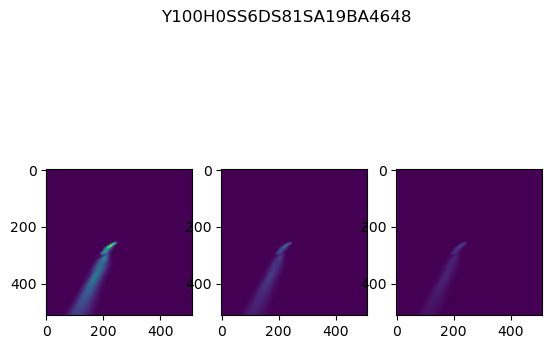

In [465]:
#use a random folder to open the pickle file and get the metadata
idx = np.random.randint(len(folders))
folder = folders[idx]
print(f"folder: {folder}", idx)
with open(sourceDirectory + folder + f'/{folder}.pkl', 'rb') as f:
    data = pickle.load(f)
    print(data.shape)

#plot the data for the first three timesteps
# use the same scale on the colorbar for all plots
#find the max and min of the data
maxVal = np.max(data)
minVal = np.min(data)
plt.figure()
plt.subplot(131)
plt.imshow(data[0], vmin=minVal, vmax=maxVal)
plt.subplot(132)
plt.imshow(data[1], vmin=minVal, vmax=maxVal)
plt.subplot(133)
plt.imshow(data[2], vmin=minVal, vmax=maxVal)
#provide a super label using the folder name
plt.suptitle(folder)
plt.show()

folder: Y100H18SS3DS235SA15BA5483, idx: 1821


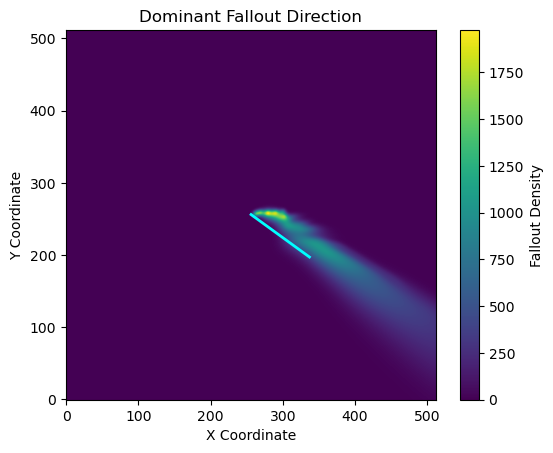

In [544]:
from scipy.optimize import curve_fit

idx = 310
idx = np.random.randint(len(folders))
folder = folders[idx]
print(f"folder: {folder}, idx: {idx}")
with open(sourceDirectory + folder + f'/{folder}.pkl', 'rb') as f:
    data = pickle.load(f)

#the blast is at the center of the image, look at the first timestep to determine the axis of fallout pattern
#flatten the data
data = data[0]


#use weighted linear regression to determine the axis of the fallout pattern
# Define a threshold for significant fallout
threshold = 10

falloutIndices = np.nonzero(data > threshold)
falloutX = np.array(falloutIndices[1])
falloutY = np.array(falloutIndices[0])
weights = data[falloutY, falloutX]  # Use traffic density as weights

# Define a linear function
def linear_func(x, slope, intercept):
    return slope * x + intercept

# Fit the line using weighted linear regression
popt, pcov = curve_fit(linear_func, falloutX, falloutY, sigma=1/weights, absolute_sigma=True)

# Extract the parameters
slope, intercept = popt

# Create a that starts at the center of the image and goes in the direction of the fallout for 100 pixels along the axis
#if the slope is negative, the fallout is to the left, if the slope is positive, the fallout is to the right
totalDistance = 100
xDist = np.sqrt(totalDistance**2 / (1 + slope**2))
yDist = slope * xDist

# determine the mean x and y values of the fallout to determine the direction of the fallout
xMean = np.mean(falloutX)
yMean = np.mean(falloutY)

# there are 4 quadrants to consider
# if the slope is positive and the mean x is less than the center of the image, the fallout is in the upper right quadrant
# if the slope is positive and the mean x is greater than the center of the image, the fallout is in the lower right quadrant
# if the slope is negative and the mean x is less than the center of the image, the fallout is in the upper left quadrant
# if the slope is negative and the mean x is greater than the center of the image, the fallout is in the lower left quadrant

if xMean > data.shape[1]//2 and yMean > data.shape[0]//2:
    pass
elif xMean < data.shape[1]//2 and yMean > data.shape[0]//2:
    xDist = -xDist
    yDist = -yDist
elif xMean < data.shape[1]//2 and yMean < data.shape[0]//2:
    xDist = -xDist
    yDist = -yDist
elif xMean > data.shape[1]//2 and yMean < data.shape[0]//2:
    pass

# always start from the center
x_fit = np.array([data.shape[1]//2, data.shape[1]//2 + xDist])
y_fit = np.array([data.shape[0]//2, data.shape[0]//2 + yDist])

# Plotting
plt.imshow(data, origin='lower')
plt.colorbar(label='Fallout Density')
plt.plot(x_fit, y_fit, 'cyan', linewidth=2)
plt.title('Dominant Fallout Direction')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()
